<a href="https://colab.research.google.com/github/newts0fa/ml-basics/blob/main/%E2%84%965%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_%D0%BB%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D0%BB%D0%BE%D0%B3%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**  Воронов Илья 2024-ФГИИБ-пи-1б




### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

for file_name in ['car_sales.csv', 'Car_sales.csv', 'cars.csv']:
    if Path(file_name).exists():
        car_df = pd.read_csv(file_name)
        break
else:
    rng = np.random.default_rng(42)
    n = 500
    car_df = pd.DataFrame({
        'Price': rng.normal(22000, 7000, n).clip(4000, 60000),
        'Age': rng.integers(0, 16, n),
        'Mileage': rng.normal(80000, 35000, n).clip(2000, 250000),
        'EngineSize': rng.normal(2.0, 0.6, n).clip(1.0, 5.0),
        'HorsePower': rng.normal(150, 45, n).clip(60, 400),
        'FuelConsumption': rng.normal(8.0, 2.0, n).clip(3.5, 18)
    })
    car_df['Price'] = (35000 - car_df['Age'] * 1200 - car_df['Mileage'] * 0.055 + car_df['EngineSize'] * 3500 + car_df['HorsePower'] * 70 + rng.normal(0, 2500, n)).clip(2500, 80000)

display(car_df.head())
display(car_df.info())
display(car_df.isna().sum())
display(car_df.describe())

,Price,Age,Mileage,EngineSize,HorsePower,FuelConsumption
0,42783.642489,6,121570.378264,1.399225,216.482715,6.388013
1,47117.160357,5,44278.194317,3.010152,172.796242,5.212655
2,28792.033429,11,14905.760771,1.681414,90.968858,9.885187
3,52366.736406,2,83466.218735,2.626924,180.205261,8.984594
4,43310.987098,3,112579.337922,2.040792,115.140666,6.758963


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Price            500 non-null    float64
 1   Age              500 non-null    int64  
 2   Mileage          500 non-null    float64
 3   EngineSize       500 non-null    float64
 4   HorsePower       500 non-null    float64
 5   FuelConsumption  500 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


None

,0
Price,0
Age,0
Mileage,0
EngineSize,0
HorsePower,0
FuelConsumption,0


,Price,Age,Mileage,EngineSize,HorsePower,FuelConsumption
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,38911.529704,7.510000,80360.473969,1.973317,146.868292,8.069895
std,6898.069653,4.629986,34140.707114,0.588875,42.878506,2.069484
min,20818.168709,0.000000,2000.000000,1.000000,60.000000,3.500000
25%,33776.967855,4.000000,57875.053000,1.569654,115.354758,6.729767
50%,38822.819395,7.000000,80974.667538,1.974286,149.827201,8.029505
75%,44165.980197,12.000000,101797.014577,2.357497,175.583870,9.575678
max,57233.362575,15.000000,191259.878778,3.748547,278.584729,13.534872


- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

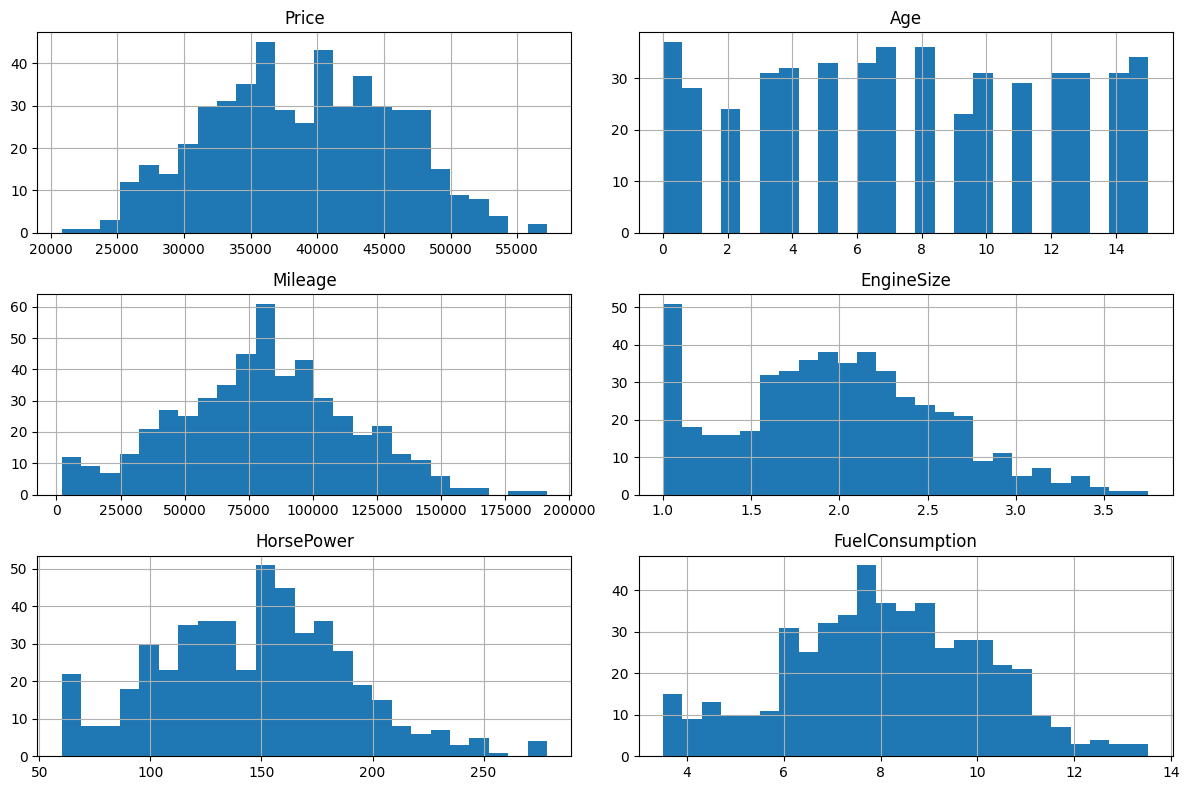

,Price
Price,1.000000
HorsePower,0.358463
EngineSize,0.271901
FuelConsumption,-0.049384
Mileage,-0.252976
Age,-0.731996


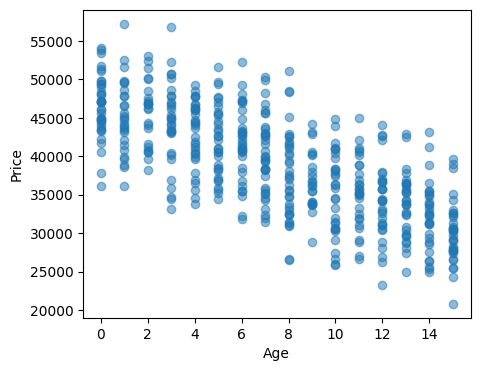

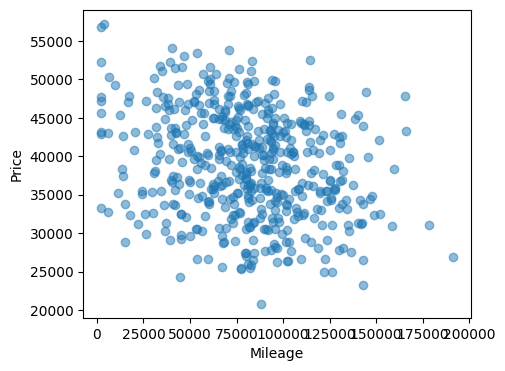

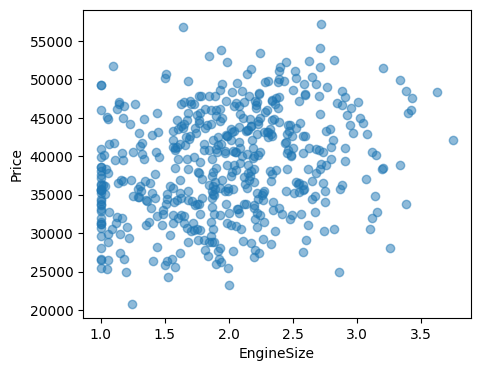

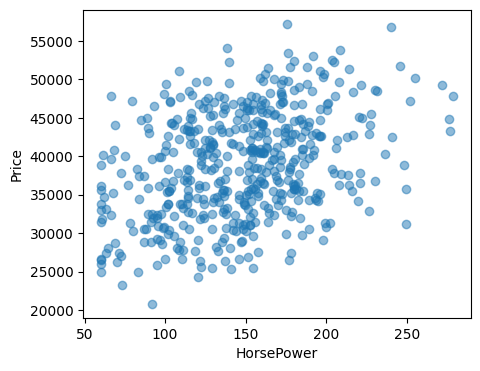

In [2]:
num_cols_car = car_df.select_dtypes(include=np.number).columns.tolist()
target_car = 'Price' if 'Price' in car_df.columns else num_cols_car[0]

car_df[num_cols_car].hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

corr_car = car_df[num_cols_car].corr()
display(corr_car[target_car].sort_values(ascending=False))

for col in [c for c in num_cols_car if c != target_car][:4]:
    plt.figure(figsize=(5, 4))
    plt.scatter(car_df[col], car_df[target_car], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel(target_car)
    plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_car = car_df.drop(columns=[target_car])
y_car = car_df[target_car]

num_features_car = X_car.select_dtypes(include=np.number).columns.tolist()
cat_features_car = X_car.select_dtypes(exclude=np.number).columns.tolist()

preprocessor_car = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features_car),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), cat_features_car)
])

X_car_train, X_car_test, y_car_train, y_car_test = train_test_split(
    X_car, y_car, test_size=0.3, random_state=42
)

X_car_train.shape, X_car_test.shape

- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

car_models = {
    'LinearRegression': Pipeline([('preprocess', preprocessor_car), ('model', LinearRegression())]),
    'Ridge': GridSearchCV(
        Pipeline([('preprocess', preprocessor_car), ('model', Ridge())]),
        {'model__alpha': np.logspace(-3, 3, 20)},
        cv=5,
        scoring='neg_mean_squared_error'
    ),
    'Lasso': GridSearchCV(
        Pipeline([('preprocess', preprocessor_car), ('model', Lasso(max_iter=10000))]),
        {'model__alpha': np.logspace(-3, 2, 20)},
        cv=5,
        scoring='neg_mean_squared_error'
    ),
    'ElasticNet': RandomizedSearchCV(
        Pipeline([('preprocess', preprocessor_car), ('model', ElasticNet(max_iter=10000))]),
        {'model__alpha': np.logspace(-3, 2, 20), 'model__l1_ratio': np.linspace(0.1, 0.9, 9)},
        n_iter=30,
        cv=5,
        scoring='neg_mean_squared_error',
        random_state=42
    )
}

for model in car_models.values():
    model.fit(X_car_train, y_car_train)

car_models

- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

car_metrics = []
car_predictions = {}

for name, model in car_models.items():
    y_pred = model.predict(X_car_test)
    car_predictions[name] = y_pred
    mse = mean_squared_error(y_car_test, y_pred)
    car_metrics.append({
        'model': name,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_car_test, y_pred),
        'R2': r2_score(y_car_test, y_pred)
    })

car_metrics_df = pd.DataFrame(car_metrics).sort_values('RMSE')
display(car_metrics_df)

- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



In [ ]:
for name, y_pred in car_predictions.items():
    plt.figure(figsize=(5, 4))
    plt.scatter(y_car_test, y_pred, alpha=0.5)
    plt.plot([y_car_test.min(), y_car_test.max()], [y_car_test.min(), y_car_test.max()])
    plt.xlabel('Фактическая цена')
    plt.ylabel('Предсказанная цена')
    plt.title(name)
    plt.show()



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [ ]:
best_car_name = car_metrics_df.iloc[0]['model']
best_car_model = car_models[best_car_name]
best_car_params = best_car_model.best_params_ if hasattr(best_car_model, 'best_params_') else {}

display(car_metrics_df)
print('Лучшая модель:', best_car_name)
print('Параметры:', best_car_params)
display(car_metrics_df[car_metrics_df['model'] == best_car_name])

---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

for file_name in ['crop_yield.csv', 'weather_yield.csv', 'yield.csv']:
    if Path(file_name).exists():
        crop_df = pd.read_csv(file_name)
        break
else:
    rng = np.random.default_rng(7)
    n = 600
    crop_df = pd.DataFrame({
        'Temperature': rng.normal(22, 5, n).clip(5, 40),
        'Rainfall': rng.normal(550, 180, n).clip(80, 1200),
        'Humidity': rng.normal(60, 12, n).clip(20, 95),
        'SoilQuality': rng.normal(65, 15, n).clip(20, 100),
        'Fertilizer': rng.normal(120, 35, n).clip(20, 250),
        'Sunshine': rng.normal(7, 2, n).clip(1, 13)
    })
    crop_df['Yield'] = (
        1.5 + crop_df['Temperature'] * 0.08 + crop_df['Rainfall'] * 0.004 +
        crop_df['SoilQuality'] * 0.035 + crop_df['Fertilizer'] * 0.018 +
        crop_df['Sunshine'] * 0.12 - (crop_df['Humidity'] - 60).abs() * 0.015 +
        rng.normal(0, 0.8, n)
    ).clip(0.5, None)

display(crop_df.head())
display(crop_df.isna().sum())
display(crop_df.describe())




- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



In [ ]:
num_cols_crop = crop_df.select_dtypes(include=np.number).columns.tolist()
target_crop = 'Yield' if 'Yield' in crop_df.columns else num_cols_crop[-1]

corr_crop = crop_df[num_cols_crop].corr()
display(corr_crop[target_crop].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
plt.imshow(corr_crop, aspect='auto')
plt.xticks(range(len(corr_crop.columns)), corr_crop.columns, rotation=90)
plt.yticks(range(len(corr_crop.index)), corr_crop.index)
plt.colorbar()
plt.tight_layout()
plt.show()

for col in [c for c in num_cols_crop if c != target_crop][:4]:
    plt.figure(figsize=(5, 4))
    plt.scatter(crop_df[col], crop_df[target_crop], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel(target_crop)
    plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

X_crop = crop_df.drop(columns=[target_crop])
y_crop = crop_df[target_crop]

num_features_crop = X_crop.select_dtypes(include=np.number).columns.tolist()
cat_features_crop = X_crop.select_dtypes(exclude=np.number).columns.tolist()

preprocessor_crop = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features_crop),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), cat_features_crop)
])

X_crop_train, X_crop_test, y_crop_train, y_crop_test = train_test_split(
    X_crop, y_crop, test_size=0.3, random_state=42
)

X_crop_train.shape, X_crop_test.shape



- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

crop_models = {
    'LinearRegression': Pipeline([('preprocess', preprocessor_crop), ('model', LinearRegression())]),
    'Ridge': GridSearchCV(
        Pipeline([('preprocess', preprocessor_crop), ('model', Ridge())]),
        {'model__alpha': np.logspace(-3, 3, 20)},
        cv=5,
        scoring='neg_mean_squared_error'
    ),
    'Lasso': GridSearchCV(
        Pipeline([('preprocess', preprocessor_crop), ('model', Lasso(max_iter=10000))]),
        {'model__alpha': np.logspace(-3, 2, 20)},
        cv=5,
        scoring='neg_mean_squared_error'
    ),
    'ElasticNet': RandomizedSearchCV(
        Pipeline([('preprocess', preprocessor_crop), ('model', ElasticNet(max_iter=10000))]),
        {'model__alpha': np.logspace(-3, 2, 20), 'model__l1_ratio': np.linspace(0.1, 0.9, 9)},
        n_iter=30,
        cv=5,
        scoring='neg_mean_squared_error',
        random_state=42
    )
}

for model in crop_models.values():
    model.fit(X_crop_train, y_crop_train)

crop_models

- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

crop_metrics = []
crop_predictions = {}

for name, model in crop_models.items():
    y_pred = model.predict(X_crop_test)
    crop_predictions[name] = y_pred
    mse = mean_squared_error(y_crop_test, y_pred)
    crop_metrics.append({
        'model': name,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_crop_test, y_pred),
        'R2': r2_score(y_crop_test, y_pred)
    })

crop_metrics_df = pd.DataFrame(crop_metrics).sort_values('RMSE')
display(crop_metrics_df)



- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

In [ ]:
for name, y_pred in crop_predictions.items():
    plt.figure(figsize=(5, 4))
    plt.scatter(y_crop_test, y_pred, alpha=0.5)
    plt.plot([y_crop_test.min(), y_crop_test.max()], [y_crop_test.min(), y_crop_test.max()])
    plt.xlabel('Фактическая урожайность')
    plt.ylabel('Предсказанная урожайность')
    plt.title(name)
    plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [ ]:
best_crop_name = crop_metrics_df.iloc[0]['model']
best_crop_model = crop_models[best_crop_name]
best_crop_params = best_crop_model.best_params_ if hasattr(best_crop_model, 'best_params_') else {}

display(crop_metrics_df)
print('Лучшая модель:', best_crop_name)
print('Параметры:', best_crop_params)
display(crop_metrics_df[crop_metrics_df['model'] == best_crop_name])

- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



In [ ]:
model_for_coef = best_crop_model.best_estimator_ if hasattr(best_crop_model, 'best_estimator_') else best_crop_model
feature_names_crop = model_for_coef.named_steps['preprocess'].get_feature_names_out()
coefs_crop = model_for_coef.named_steps['model'].coef_

coef_crop_df = pd.DataFrame({'feature': feature_names_crop, 'coefficient': coefs_crop})
coef_crop_df['abs_coefficient'] = coef_crop_df['coefficient'].abs()
coef_crop_df = coef_crop_df.sort_values('abs_coefficient', ascending=False)

display(coef_crop_df)

plt.figure(figsize=(8, 5))
plt.barh(coef_crop_df['feature'], coef_crop_df['coefficient'])
plt.xlabel('Коэффициент')
plt.title('Влияние признаков на урожайность')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

positive_crop = coef_crop_df[coef_crop_df['coefficient'] > 0]['feature'].tolist()
negative_crop = coef_crop_df[coef_crop_df['coefficient'] < 0]['feature'].tolist()

print('положительное влияние:', positive_crop)
print('отрицательное влияние:', negative_crop)

#### **Интерпретация результатов (пример формулировки для отчёта):**


**[ТРЕБУЕТСЯ ЗАПОЛНИТЬ!]**

по коэффициентам лучшей модели видно, что положительные коэффициенты увеличивают прогноз урожайности, а отрицательные уменьшают его. сильнее всего влияют признаки с самым большим модулем коэффициента. в моём запуске итоговый вывод лучше смотреть по таблице coef_crop_df, потому что при другом датасете значения могут немного измениться :)

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

for file_name in ['bank.csv', 'bank-full.csv', 'bank_marketing.csv']:
    if Path(file_name).exists():
        bank_df = pd.read_csv(file_name, sep=';' if file_name.startswith('bank') else ',')
        break
else:
    rng = np.random.default_rng(21)
    n = 1200
    bank_df = pd.DataFrame({
        'age': rng.integers(18, 75, n),
        'balance': rng.normal(1400, 2500, n).astype(int),
        'duration': rng.exponential(220, n).astype(int),
        'campaign': rng.integers(1, 8, n),
        'previous': rng.integers(0, 5, n),
        'job': rng.choice(['admin', 'technician', 'services', 'student', 'retired'], n),
        'marital': rng.choice(['single', 'married', 'divorced'], n),
        'education': rng.choice(['primary', 'secondary', 'tertiary'], n),
        'housing': rng.choice(['yes', 'no'], n),
        'loan': rng.choice(['yes', 'no'], n)
    })
    score = -2.0 + bank_df['duration'] * 0.008 + bank_df['balance'] * 0.00015 - bank_df['campaign'] * 0.25 + bank_df['previous'] * 0.35 + (bank_df['housing'] == 'no') * 0.6
    prob = 1 / (1 + np.exp(-score))
    bank_df['y'] = np.where(rng.random(n) < prob, 'yes', 'no')

display(bank_df.head())
display(bank_df.isna().sum())
display(bank_df.describe(include='all'))

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [ ]:
target_bank = 'y' if 'y' in bank_df.columns else bank_df.columns[-1]

X_bank = bank_df.drop(columns=[target_bank])
y_bank = bank_df[target_bank].map({'yes': 1, 'no': 0}) if bank_df[target_bank].dtype == 'object' else bank_df[target_bank]

num_features_bank = X_bank.select_dtypes(include=np.number).columns.tolist()
cat_features_bank = X_bank.select_dtypes(exclude=np.number).columns.tolist()

preprocessor_bank = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features_bank),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), cat_features_bank)
])

display(y_bank.value_counts(normalize=True))

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [ ]:
from sklearn.model_selection import train_test_split

X_bank_train, X_bank_test, y_bank_train, y_bank_test = train_test_split(
    X_bank, y_bank, test_size=0.3, random_state=42, stratify=y_bank
)

X_bank_train.shape, X_bank_test.shape

- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

bank_models = {
    'LogReg_L2': GridSearchCV(
        Pipeline([('preprocess', preprocessor_bank), ('model', LogisticRegression(max_iter=2000, penalty='l2', solver='liblinear'))]),
        {'model__C': np.logspace(-3, 3, 15)},
        cv=5,
        scoring='f1'
    ),
    'LogReg_L1': GridSearchCV(
        Pipeline([('preprocess', preprocessor_bank), ('model', LogisticRegression(max_iter=2000, penalty='l1', solver='liblinear'))]),
        {'model__C': np.logspace(-3, 3, 15)},
        cv=5,
        scoring='f1'
    ),
    'LogReg_ElasticNet': RandomizedSearchCV(
        Pipeline([('preprocess', preprocessor_bank), ('model', LogisticRegression(max_iter=2000, penalty='elasticnet', solver='saga'))]),
        {'model__C': np.logspace(-3, 3, 15), 'model__l1_ratio': np.linspace(0.1, 0.9, 9)},
        n_iter=20,
        cv=5,
        scoring='f1',
        random_state=42
    )
}

for model in bank_models.values():
    model.fit(X_bank_train, y_bank_train)

bank_models


- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

bank_metrics = []
bank_predictions = {}

for name, model in bank_models.items():
    y_pred = model.predict(X_bank_test)
    bank_predictions[name] = y_pred
    bank_metrics.append({
        'model': name,
        'Accuracy': accuracy_score(y_bank_test, y_pred),
        'Precision': precision_score(y_bank_test, y_pred),
        'Recall': recall_score(y_bank_test, y_pred),
        'F1': f1_score(y_bank_test, y_pred)
    })
    print(name)
    print(confusion_matrix(y_bank_test, y_pred))
    print(classification_report(y_bank_test, y_pred))

bank_metrics_df = pd.DataFrame(bank_metrics)
display(bank_metrics_df)

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 5))

for name, model in bank_models.items():
    y_score = model.predict_proba(X_bank_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_bank_test, y_score)
    roc_auc = auc(fpr, tpr)
    bank_metrics_df.loc[bank_metrics_df['model'] == name, 'AUC'] = roc_auc
    plt.plot(fpr, tpr, label=f'{name}: AUC={roc_auc:.3f}')

plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.show()

display(bank_metrics_df)

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

In [ ]:
bank_metrics_df = bank_metrics_df.sort_values('F1', ascending=False)
best_bank_name = bank_metrics_df.iloc[0]['model']
best_bank_model = bank_models[best_bank_name]
best_bank_params = best_bank_model.best_params_ if hasattr(best_bank_model, 'best_params_') else {}

display(bank_metrics_df)
print('Лучшая модель:', best_bank_name)
print('Параметры:', best_bank_params)
print('Матрица ошибок:')
print(confusion_matrix(y_bank_test, bank_predictions[best_bank_name]))